In [22]:
import pandas as pd
from pathlib import Path
from datetime import date

In [23]:
lmp_dir = Path("../data/raw/lmp")
files = sorted(lmp_dir.glob("*_da_expost_lmp.csv"))
print(len(files), "files found")

3653 files found


In [24]:
def load_flambeau_lmp(path):
    df = pd.read_csv(path, skiprows=4)
    row = df[(df["Node"] == "DPC.FLAMBEAU") & (df["Value"] == "LMP")]
    if row.empty:
        return None

    file_date = pd.to_datetime(path.name[:8], format="%Y%m%d")

    he_cols = [c for c in df.columns if c.startswith("HE ")]
    long = row.melt(id_vars=["Node", "Type", "Value"], value_vars=he_cols, var_name="HE", value_name="LMP")
    long["hour"] = long["HE"].str.replace("HE ", "").astype(int)
    long["timestamp"] = file_date + pd.to_timedelta(long["hour"] - 1, unit="h")
    return long[["timestamp", "LMP"]]

In [25]:
test = load_flambeau_lmp(files[0])
print(test)

             timestamp    LMP
0  2016-01-01 00:00:00  17.35
1  2016-01-01 01:00:00  17.50
2  2016-01-01 02:00:00  15.01
3  2016-01-01 03:00:00  13.93
4  2016-01-01 04:00:00  13.28
5  2016-01-01 05:00:00  15.42
6  2016-01-01 06:00:00  18.13
7  2016-01-01 07:00:00  19.20
8  2016-01-01 08:00:00  19.91
9  2016-01-01 09:00:00  19.91
10 2016-01-01 10:00:00  20.86
11 2016-01-01 11:00:00  20.76
12 2016-01-01 12:00:00  20.47
13 2016-01-01 13:00:00  19.74
14 2016-01-01 14:00:00  19.03
15 2016-01-01 15:00:00  19.07
16 2016-01-01 16:00:00  19.98
17 2016-01-01 17:00:00  23.58
18 2016-01-01 18:00:00  25.35
19 2016-01-01 19:00:00  24.06
20 2016-01-01 20:00:00  23.59
21 2016-01-01 21:00:00  22.15
22 2016-01-01 22:00:00  21.38
23 2016-01-01 23:00:00  20.82


In [26]:
cache_path = Path("../data/processed/lmp_hourly.csv")

if cache_path.exists():
    lmp_df = pd.read_csv(cache_path, parse_dates=["timestamp"])
else:
    all_lmp = []
    for f in files:
        result = load_flambeau_lmp(f)
        if result is not None:
            all_lmp.append(result)
        else:
            print("missing Flambeau row:", f.name)
    lmp_df = pd.concat(all_lmp, ignore_index=True).sort_values("timestamp").reset_index(drop=True)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    lmp_df.to_csv(cache_path, index=False)

print(lmp_df.shape)
lmp_df.head()

(87672, 2)


,timestamp,LMP
0,2016-01-01 00:00:00,17.35
1,2016-01-01 01:00:00,17.50
2,2016-01-01 02:00:00,15.01
3,2016-01-01 03:00:00,13.93
4,2016-01-01 04:00:00,13.28


In [27]:
gen_df = pd.read_csv("../data/raw/flambeau_gen.csv", na_values=["undefined"])
gen_df["Timestamp"] = pd.to_datetime(gen_df["Timestamp"])
gen_df = gen_df.rename(columns={"Flambeau (MW)": "MW"})
gen_df = gen_df.sort_values("Timestamp").reset_index(drop=True)

print(gen_df.shape)
print(gen_df["MW"].isna().sum(), "missing values")

(1050, 2)
84 missing values


In [28]:
# Drop rows with missing MW values
first_valid = gen_df["MW"].first_valid_index()
gen_df = gen_df.loc[first_valid:].reset_index(drop=True)

# Fill any remaining internal gaps by interpolating between known points
gen_df["MW"] = gen_df["MW"].interpolate(method="linear")

print(gen_df["MW"].isna().sum(), "missing values after cleaning")
print(gen_df.head())

0 missing values after cleaning
                  Timestamp        MW
0 2016-01-03 06:00:00+00:00  6.810214
1 2016-01-07 06:00:00+00:00  8.851151
2 2016-01-11 06:00:00+00:00  6.353286
3 2016-01-15 06:00:00+00:00  7.469466
4 2016-01-19 06:00:00+00:00  7.503665


In [29]:
# Align generation timestamps to the same convention as LMP
gen_df["Timestamp"] = gen_df["Timestamp"].dt.tz_convert("Etc/GMT+5").dt.tz_localize(None)

lmp_df = lmp_df.sort_values("timestamp").reset_index(drop=True)
gen_df = gen_df.sort_values("Timestamp").reset_index(drop=True)

# For every hourly LMP row, attach most recent generation value at or before that timestamp
merged = pd.merge_asof(
    lmp_df, gen_df,
    left_on="timestamp", right_on="Timestamp",
    direction="backward"
)

# Hours before the very first generation reading will have nothing to carry forward, so drop those rows
merged = merged.dropna(subset=["MW"]).reset_index(drop=True)

# Revenue per hour: MW held from the last reading * that hour's real-time LMP
merged["revenue"] = merged["MW"] * merged["LMP"]

print(merged.shape)
merged.head(10)


(87623, 5)


,timestamp,LMP,Timestamp,MW,revenue
0,2016-01-03 01:00:00,16.47,2016-01-03 01:00:00,6.810214,112.164225
1,2016-01-03 02:00:00,16.92,2016-01-03 01:00:00,6.810214,115.228821
2,2016-01-03 03:00:00,17.33,2016-01-03 01:00:00,6.810214,118.021009
3,2016-01-03 04:00:00,17.64,2016-01-03 01:00:00,6.810214,120.132175
4,2016-01-03 05:00:00,18.10,2016-01-03 01:00:00,6.810214,123.264873
5,2016-01-03 06:00:00,18.91,2016-01-03 01:00:00,6.810214,128.781147
6,2016-01-03 07:00:00,19.51,2016-01-03 01:00:00,6.810214,132.867275
7,2016-01-03 08:00:00,20.61,2016-01-03 01:00:00,6.810214,140.358511
8,2016-01-03 09:00:00,20.83,2016-01-03 01:00:00,6.810214,141.856758
9,2016-01-03 10:00:00,22.01,2016-01-03 01:00:00,6.810214,149.892810


In [30]:
# Roll hourly revenue up to daily
merged["date"] = merged["timestamp"].dt.date
daily = merged.groupby("date")["revenue"].sum().reset_index()
daily["date"] = pd.to_datetime(daily["date"])

daily["iso_year"] = daily["date"].dt.isocalendar().year
daily["iso_week"] = daily["date"].dt.isocalendar().week

In [31]:
# Define my candidate 2-week windows as consecutive week pairs
# TODO - see about checking every possible 14 day start date
daily["window_id"] = ((daily["iso_week"] - 1) // 2) + 1

In [32]:
# Get one total revenue number per window per year
window_year_revenue = daily.groupby(["iso_year", "window_id"])["revenue"].sum().reset_index()

In [33]:
# Compute mean and spread across all 10 years for each window
window_stats = (
    window_year_revenue
    .groupby("window_id")["revenue"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
    .sort_values("mean")
)
window_stats.head(10)

,window_id,mean,std,min,max,count
26,27,13185.654985,13908.158207,3351.102003,23020.207967,2
4,5,61498.925602,30211.852502,30467.012464,141811.994195,10
2,3,63730.598850,13543.459061,42044.867432,77593.424186,10
17,18,65517.516480,24343.489167,30341.332754,103271.302484,10
25,26,65758.920901,17621.190965,45093.589024,106981.343669,10
23,24,68736.289735,16279.300795,53406.011186,104051.467155,10
16,17,69077.061417,16802.445821,45423.345669,94081.083733,10
0,1,69409.272853,24138.125008,11652.014563,98606.143245,11
24,25,71028.333324,16000.798052,46720.650842,100138.636917,10
3,4,71061.716903,38859.844848,42367.772716,170666.420803,10


In [34]:
# Filter for windows with full data support, then translate top 3 into real 2027 dates
full_years = window_stats["count"].max()
candidates = window_stats[window_stats["count"] >= full_years - 1].sort_values("mean").head(3)

def window_to_2027_dates(window_id):
    week_start = (window_id - 1) * 2 + 1
    week_end = week_start + 1
    start = date.fromisocalendar(2027, week_start, 1)   # Monday of first week
    end = date.fromisocalendar(2027, week_end, 7)       # Sunday of second week
    return start, end

for _, row in candidates.iterrows():
    start, end = window_to_2027_dates(int(row["window_id"]))
    print(f"{start} to {end}: mean lost revenue ${row['mean']:,.0f} "
          f"(range ${row['min']:,.0f}, n={int(row['count'])} years)")

2027-03-01 to 2027-03-14: mean lost revenue $61,499 (range $30,467, n=10 years)
2027-02-01 to 2027-02-14: mean lost revenue $63,731 (range $42,045, n=10 years)
2027-08-30 to 2027-09-12: mean lost revenue $65,518 (range $30,341, n=10 years)


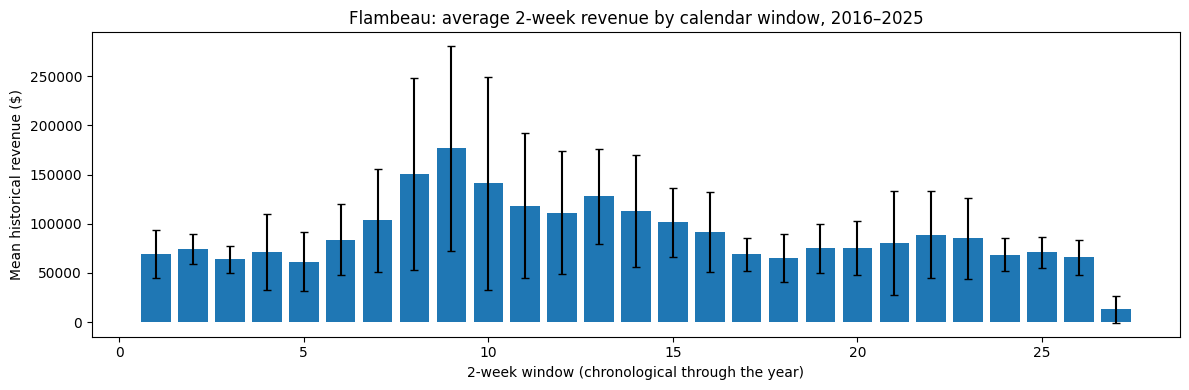

In [35]:
import matplotlib.pyplot as plt

window_stats_sorted = window_stats.sort_values("window_id")

plt.figure(figsize=(12, 4))
plt.bar(window_stats_sorted["window_id"], window_stats_sorted["mean"],
        yerr=window_stats_sorted["std"], capsize=3)
plt.xlabel("2-week window (chronological through the year)")
plt.ylabel("Mean historical revenue ($)")
plt.title("Flambeau: average 2-week revenue by calendar window, 2016–2025")
plt.tight_layout()
plt.show()